<a href="https://colab.research.google.com/github/2024akcs4377f-spec/ML-assignment-2/blob/Error-Analysis/Error_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Setup and Synthetic Data Generation
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Generate a synthetic dataset for binary classification
np.random.seed(42)
n_samples = 1000
n_features = 5

X = np.random.rand(n_samples, n_features) * 10
y = (X[:, 0] + X[:, 1] + np.random.randn(n_samples) * 3 > 12).astype(int)

# Add a synthetic 'sensitive_attribute' for subgroup analysis and fairness
sensitive_attribute = np.random.choice(['Group_A', 'Group_B'], size=n_samples, p=[0.5, 0.5])

df = pd.DataFrame(X, columns=[f'feature_{i+1}' for i in range(n_features)])
df['sensitive_attribute'] = sensitive_attribute
df['target'] = y

display(df.head())
display(df['target'].value_counts())
display(df['sensitive_attribute'].value_counts())

,feature_1,feature_2,feature_3,feature_4,feature_5,sensitive_attribute,target
0,3.745401,9.507143,7.319939,5.986585,1.560186,Group_A,0
1,1.559945,0.580836,8.661761,6.011150,7.080726,Group_B,0
2,0.205845,9.699099,8.324426,2.123391,1.818250,Group_B,0
3,1.834045,3.042422,5.247564,4.319450,2.912291,Group_B,0
4,6.118529,1.394939,2.921446,3.663618,4.560700,Group_A,0


,count
target,
0,659
1,341


,count
sensitive_attribute,
Group_A,511
Group_B,489


In [2]:
X = df.drop(['target', 'sensitive_attribute'], axis=1)
y = df['target']

# Split data into training and test sets
X_train, X_test, y_train, y_test, sa_train, sa_test = train_test_split(
    X, y, df['sensitive_attribute'], test_size=0.2, random_state=42, stratify=y
)

# Initialize a Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear')

# Perform K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')

print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of CV accuracy: {cv_scores.std():.4f}")

# Train the model on the full training data for subsequent analysis
model.fit(X_train, y_train)

Cross-validation accuracy scores: [0.81875 0.8375  0.86875 0.8125  0.81875]
Mean CV accuracy: 0.8313
Standard deviation of CV accuracy: 0.0205


LogisticRegression(random_state=42, solver='liblinear')


Overall Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       132
           1       0.76      0.74      0.75        68

    accuracy                           0.83       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.83      0.83      0.83       200



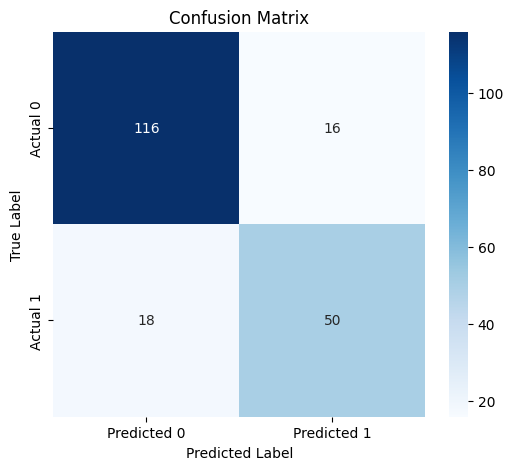


Number of misclassified samples: 34

Examples of Misclassified Samples:


,feature_1,feature_2,feature_3,feature_4,feature_5,true_label,predicted_label
28,9.624473,2.517823,4.972485,3.008783,2.848405,0,1
797,9.303984,0.953609,4.500586,3.374543,8.706885,1,0
793,7.873720,3.064328,0.402580,5.883522,3.976844,1,0
912,7.201575,2.872212,8.797524,0.492209,2.310809,1,0
419,7.928544,5.775934,6.345824,7.979142,3.959705,0,1


In [9]:
y_pred = model.predict(X_test)

print("\nOverall Classification Report on Test Set:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Identify misclassified samples
misclassified_indices = np.where(y_test != y_pred)[0]
misclassified_samples_df = X_test.iloc[misclassified_indices].copy()
misclassified_samples_df['true_label'] = y_test.iloc[misclassified_indices].values
misclassified_samples_df['predicted_label'] = y_pred[misclassified_indices]

print(f"\nNumber of misclassified samples: {len(misclassified_indices)}")
print("\nExamples of Misclassified Samples:")
display(misclassified_samples_df.head())


Performance Metrics by Subgroup:


,Group,Accuracy,Precision,Recall,F1-Score
0,Group_A,0.806122,0.684211,0.787879,0.732394
1,Group_B,0.852941,0.857143,0.685714,0.761905


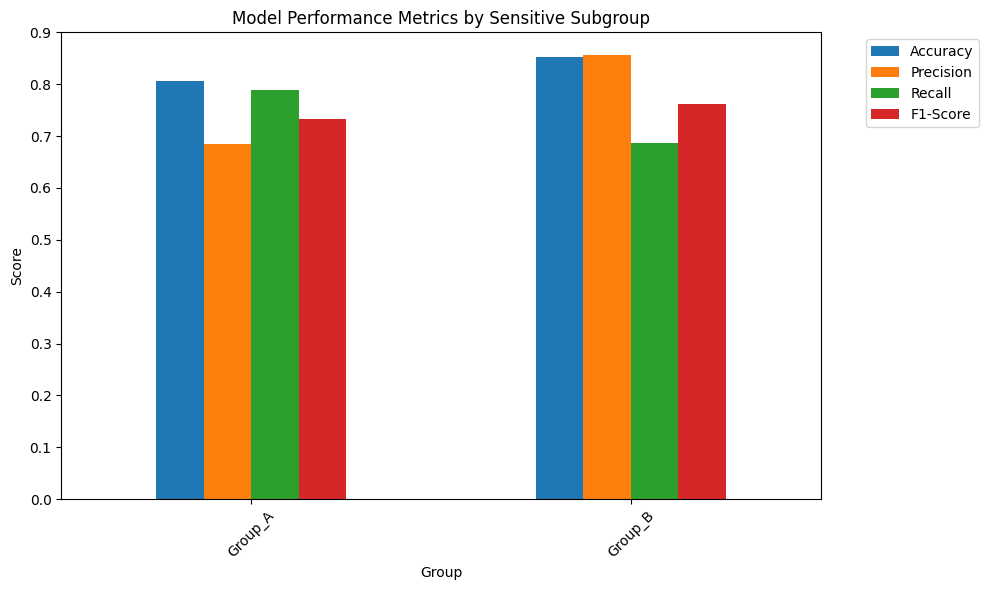

In [4]:
test_results = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred,
    'sensitive_attribute': sa_test
})

subgroup_metrics = []
for group_name in test_results['sensitive_attribute'].unique():
    group_df = test_results[test_results['sensitive_attribute'] == group_name]
    acc = accuracy_score(group_df['y_true'], group_df['y_pred'])
    prec = precision_score(group_df['y_true'], group_df['y_pred'], zero_division=0)
    rec = recall_score(group_df['y_true'], group_df['y_pred'], zero_division=0)
    f1 = f1_score(group_df['y_true'], group_df['y_pred'], zero_division=0)
    subgroup_metrics.append({'Group': group_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

subgroup_metrics_df = pd.DataFrame(subgroup_metrics)
print("\nPerformance Metrics by Subgroup:")
display(subgroup_metrics_df)

# Visualize subgroup performance
subgroup_metrics_df.set_index('Group').plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Metrics by Sensitive Subgroup')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

,Group,FPR,FNR
0,Group_A,0.184615,0.212121
1,Group_B,0.059701,0.314286


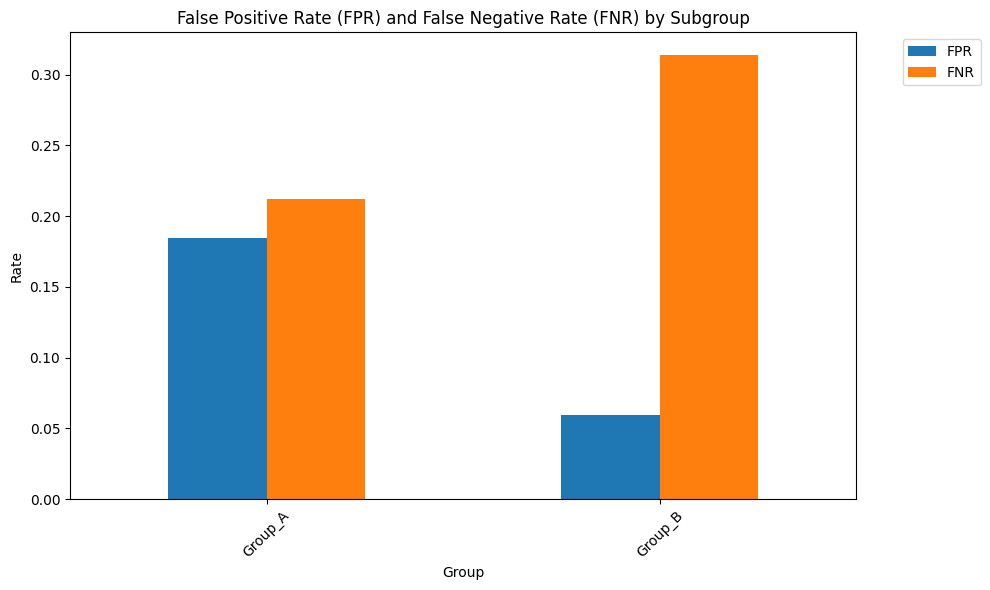


Interpretation:
Ideally, FPR and FNR should be similar across all sensitive groups for 'equalized odds'.
Significant disparities indicate potential unfairness.


In [5]:
def calculate_rates(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    return fpr, fnr

fairness_metrics = []
for group_name in test_results['sensitive_attribute'].unique():
    group_df = test_results[test_results['sensitive_attribute'] == group_name]
    fpr, fnr = calculate_rates(group_df['y_true'], group_df['y_pred'])
    fairness_metrics.append({'Group': group_name, 'FPR': fpr, 'FNR': fnr})

fairness_df = pd.DataFrame(fairness_metrics)
display(fairness_df)

# Plotting fairness metrics
fairness_df.set_index('Group').plot(kind='bar', figsize=(10, 6))
plt.title('False Positive Rate (FPR) and False Negative Rate (FNR) by Subgroup')
plt.ylabel('Rate')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("Ideally, FPR and FNR should be similar across all sensitive groups for 'equalized odds'.")
print("Significant disparities indicate potential unfairness.")

/tmp/ipykernel_3174/2098762577.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])


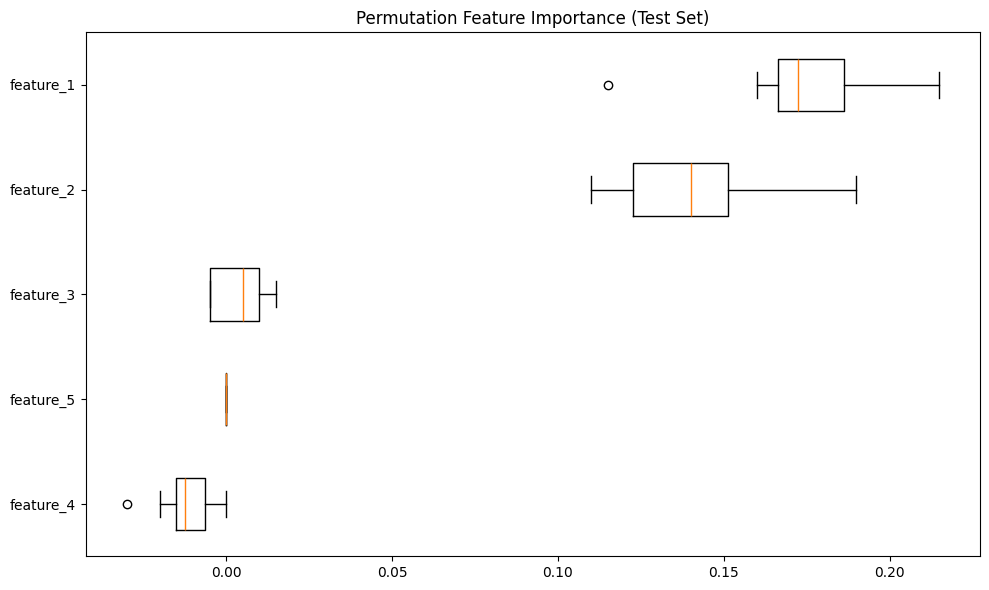


Interpretation:
Features with higher importance values have a greater impact on the model's predictions.
This helps in understanding which input variables the model relies on most.


In [6]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance on the test set
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])
plt.title("Permutation Feature Importance (Test Set)")
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("Features with higher importance values have a greater impact on the model's predictions.")
print("This helps in understanding which input variables the model relies on most.")

In [7]:
# Save the trained model
model_filename = 'logistic_regression_model.joblib'
joblib.dump(model, model_filename)
print(f"Model saved as {model_filename}")

Model saved as logistic_regression_model.joblib


In [8]:
# Load the saved model
loaded_model = joblib.load(model_filename)
print(f"Model loaded from {model_filename}")

# Test the loaded model
new_data = pd.DataFrame(np.random.rand(5, n_features) * 10, columns=[f'feature_{i+1}' for i in range(n_features)])
loaded_model_predictions = loaded_model.predict(new_data)

print("\nPredictions from loaded model on new synthetic data:")
display(new_data)
print(f"Predicted labels: {loaded_model_predictions}")

Model loaded from logistic_regression_model.joblib

Predictions from loaded model on new synthetic data:


,feature_1,feature_2,feature_3,feature_4,feature_5
0,6.415797,0.234330,4.301759,8.750087,3.014562
1,0.945563,7.583848,6.060138,5.703125,0.535766
2,1.404990,6.225494,2.078238,5.040701,5.448817
3,2.835072,9.484252,8.424641,7.223735,0.779939
4,1.061300,4.927813,1.607133,9.782655,1.585202


Predicted labels: [0 0 0 0 0]
